# Geodesic vs. Latent Distance Analysis
This notebook analyzes the correlation between true geodesic distances in the maze and distances learned by various models (VQ-VAE, Laplacian).

In [101]:
import matplotlib.pyplot as plt
import sys, os
import torch
import numpy as np

# Add the project root to the Python path to allow imports from the agents module
sys.path.append('..')
os.environ['ROOT_DIR'] = '..'  # this allows to use relative paths in config files

from result_inspection.experiment import Experiment
from result_inspection.toy_maze_geodesic import *
from geometry_aware_skill_discovery.laplacian_metric import LaplacianMetricCalculator
from agents.maze_agents.toy_maze.env.maze_env import Env

# 1. Configuration
maze_type = 'square_corridor'  # 'square_a', 'spiral', 'square_c', etc.
exp_name = 'curriculum/stage_1'    # Laplacian experiment name (folder name in logs)

# 2. Setup Environment and Experiment
print('Loading environment and experiment for {}...'.format(maze_type))
# Spiral 미로 환경 생성
env = Env(n=1, maze_type=maze_type, use_antigoal=False)
# 가짜 exp 객체 (visualize 함수들이 exp.learner.agent.env 구조를 기대하므로
class MockExperiment:
    def __init__(self, env):
        self.name = "spiral_debug"
        self.learner = type('obj', (object,), {
            'agent': type('obj', (object,), {'env': env}),
            'vae': None # VAE가 없어도 라플라시안 분석은 가능
        })
exp = MockExperiment(env)

# 3. Setup Laplacian Metric Calculator (Handles sorting and weight calculation)
calc = LaplacianMetricCalculator(maze_type=maze_type, exp_name=exp_name)

# 4. Setup Geodesic Calculator (Builds graph for ground truth distances)
geo_calc = GeodesicDistanceCalculator(env.maze, maze_type=maze_type, resolution=0.1)

Building Initial Maze Graph:  40%|███▉      | 391/981 [00:00<00:00, 3901.44it/s]

Loading environment and experiment for square_corridor...
Loaded Laplacian Metric Calculator for square_corridor/curriculum/stage_1
Sorted Eigenvalues: [ 0.0106  0.0383  0.09    0.1422  0.2027  0.2294  0.2356  0.2652  0.2707
  0.2977]


Building Initial Maze Graph: 100%|██████████| 981/981 [00:00<00:00, 3895.52it/s]


Graph Pruning: Kept 981 nodes (Largest Component) out of 981 initial valid nodes.


## 1. Environment Verification
Check if the shortest path is calculated correctly between two points.

Building Initial Maze Graph: 100%|██████████| 981/981 [00:00<00:00, 3851.31it/s]


Graph Pruning: Kept 981 nodes (Largest Component) out of 981 initial valid nodes.


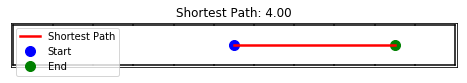

In [102]:
# Define start and end points (Adjust based on maze boundaries)
# square_a: x(-0.5, 4.5), y(-4.5, 0.5)
start_pos = (0.0, 0.0)
end_pos = (4.0, 0.0) 

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
visualize_single_geodesic_path(exp, start_pos, end_pos, ax=ax, resolution=0.1)
plt.show()

## 2. Geodesic Correlation Analysis
Compare Euclidean vs. Laplacian Latent Distance correlation with Geodesic Distance.

Building Initial Maze Graph: 100%|██████████| 216/216 [00:00<00:00, 4131.66it/s]


Graph Pruning: Kept 216 nodes (Largest Component) out of 216 initial valid nodes.
Graph Pruning: Kept 216 nodes (Largest Component) out of 216 initial valid nodes.


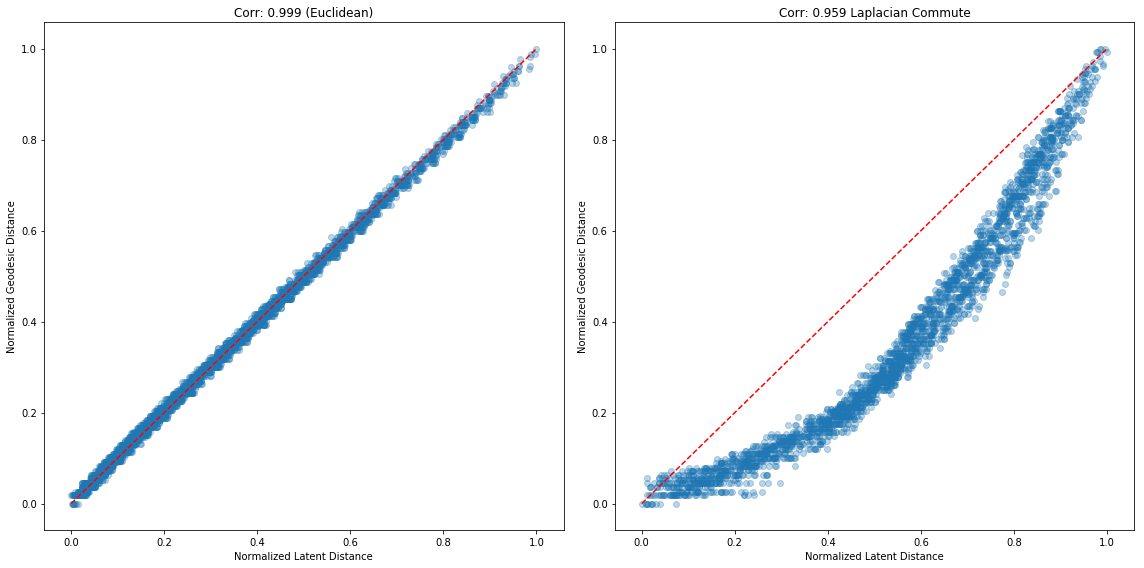

In [103]:
# --- Laplacian Metric Selection for Correlation ---
mode = 'commute' # Options: 'truncated', 'diffusion', 'commute'
n_truncated = 2  # Used if mode is 'truncated'
t_diffusion = 1.0 # Used if mode is 'diffusion'

if mode == 'truncated':
    laplacian_encoder_fn = lambda x: calc.transform_space(x, mode='truncated')[:, :n_truncated]
    title_suffix = "Laplacian Truncated n={}".format(n_truncated)
elif mode == 'diffusion':
    laplacian_encoder_fn = lambda x: calc.transform_space(x, mode='diffusion', t=t_diffusion)
    title_suffix = "Laplacian Diffusion t={}".format(t_diffusion)
else:
    laplacian_encoder_fn = lambda x: calc.transform_space(x, mode='commute')
    title_suffix = "Laplacian Commute"

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Left: Euclidean Correlation ---
visualize_geodesic_distance_correlation(
    exp,
    encoder=lambda x: x,
    ax=ax1,
    num_samples=100,
    grid_resolution=0.2,
    title_suffix='(Euclidean)'
)

# --- Right: Laplacian Correlation ---
visualize_geodesic_distance_correlation(
    exp,
    encoder=laplacian_encoder_fn,
    ax=ax2,
    num_samples=100,
    grid_resolution=0.2,
    title_suffix=title_suffix
)

plt.tight_layout()
plt.show()

## 3. Distance Heatmap Comparison
Visualize distance from a reference point to all reachable states.

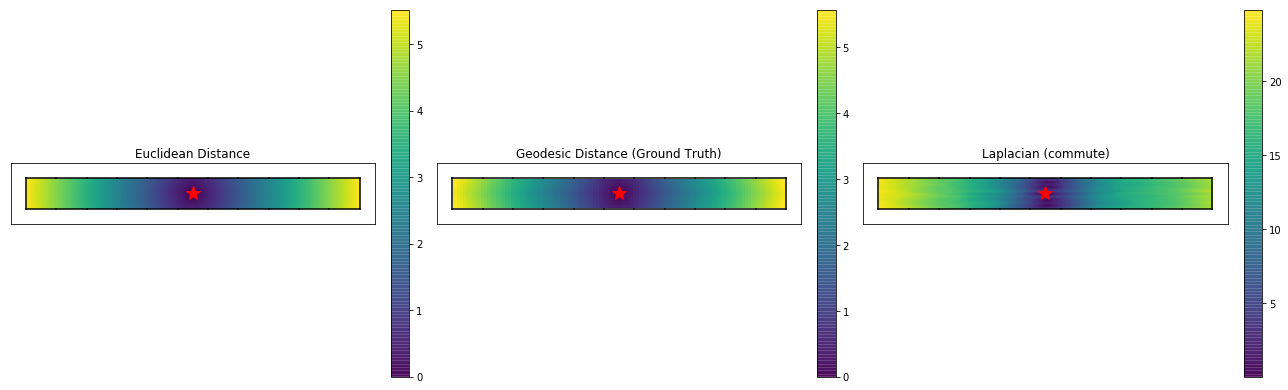

In [ ]:
# --- Laplacian Metric Selection for Heatmap ---
h_n = 1
h_t = 1000.0

s0 = (0.0, 0.0) # Reference source point

# Metric definitions
def metric_euclidean(S, s0):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    return torch.norm(S_t - s0_t, dim=1).detach().numpy()

def metric_geodesic(S, s0):
    dists = []
    s0_grid = geo_calc._get_grid_coords(s0)
    if s0_grid not in geo_calc.coord_to_node:
        return np.full(len(S), np.nan)
    s0_idx = geo_calc.coord_to_node[s0_grid]
    for p in S:
        p_grid = geo_calc._get_grid_coords(p)
        if p_grid in geo_calc.coord_to_node:
            p_idx = geo_calc.coord_to_node[p_grid]
            dists.append(geo_calc.dist_matrix[s0_idx, p_idx])
        else:
            dists.append(np.nan)
    return np.array(dists)

# Laplacian Metric Function using the calculator
metric_laplacian_fn = lambda S, s0: calc.calculate_distance(S, s0, mode=mode, n=h_n, t=h_t)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

metrics = [
    (metric_euclidean, 'Euclidean Distance'),
    (metric_geodesic, 'Geodesic Distance (Ground Truth)'),
    (metric_laplacian_fn, 'Laplacian ({0})'.format(mode))
]

for ax, (fn, title) in zip(axes, metrics):
    visualize_distance_heatmap(exp, fn, s0=s0, ax=ax, resolution=0.25, title=title)

plt.tight_layout()
plt.show()